In [12]:
import copy
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Загрузка изображения
image = cv2.imread("sar_3.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

lines count = 3
longest line has start coords: (29, 172) end coords: (223, 69) and length = 219.6


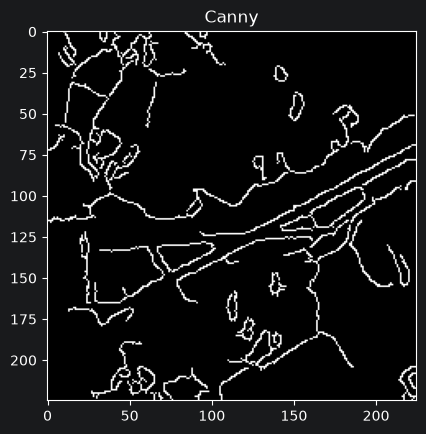

In [14]:
# Поиск наиболее протяженного участка
# сглаживание шума фильтром Гаусса
image_blur = cv2.GaussianBlur(image_gray, (9, 9), 0)

# выделение границ
canny = cv2.Canny(image_blur, 50, 150)
plt.imshow(canny, cmap="gray")
plt.title("Canny")

# получение линий с изображения
lines = cv2.HoughLinesP(canny, 1, np.pi / 180, 50, minLineLength=100, maxLineGap=20)
print("lines count =", len(lines))

# выбор самой выраженной линии
max_len = 0
for l in lines:
    x1, y1, x2, y2 = l
    length = np.hypot(x2 - x1, y2 - y1)
    if length > max_len:
        max_len = length
        pt1 = (int(x1), int(y1))
        pt2 = (int(x2), int(y2))
print("longest line has start coords:", pt1, "end coords:", pt2, "and length =", round(max_len, 1))

Text(0.5, 1.0, 'longest line')

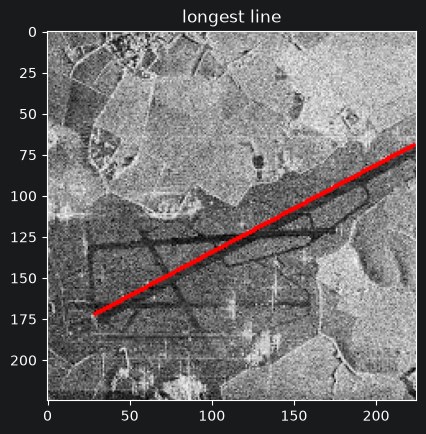

In [15]:
# Отрисовка найденной дороги
image_line = copy.deepcopy(image)
cv2.line(image_line, pt1, pt2, (255, 0, 0), 2)

plt.imshow(image_line)
plt.title("longest line")

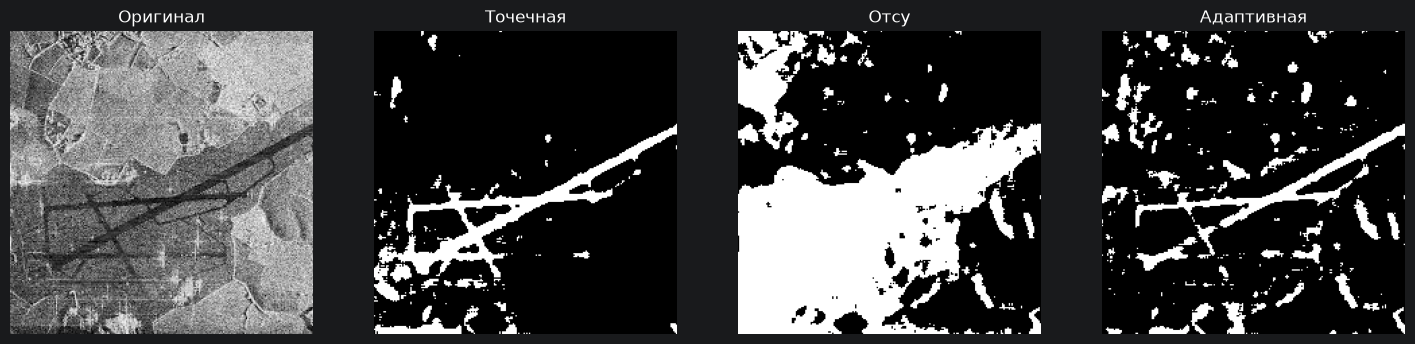

In [16]:
# 2) исследование алгоритмов бинаризации и выделение дорог

# медианный фильтр для сглаживания шума
image_median = cv2.medianBlur(image_gray, 5)

# точечная бинаризация
_, manual = cv2.threshold(image_median, 80, 255, cv2.THRESH_BINARY_INV)

# бинаризация Отсу
otsu_T, otsu = cv2.threshold(image_median, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# адаптивная бинаризация
adaptive = cv2.adaptiveThreshold(image_median, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 71, 21)

# Сравнение методов
bin_names = ["Оригинал", "Точечная", "Отсу", "Адаптивная"]
bin_images = [image_gray, manual, otsu, adaptive]

_, axes = plt.subplots(1, 4, figsize=(18, 5))
for i in range(len(bin_names)):
    axes[i].imshow(bin_images[i], cmap="gray")
    axes[i].set_title(bin_names[i])
    axes[i].axis("off")

In [17]:
# Вывод: Лучший результат показал метод точечной бинаризации